# Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import math
import seaborn as sns
import pickle
import copy

import torch
from torch import nn, Tensor

import time
import joblib

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from fm.seed import set_seed
import fm.data as data
import fm.model as model
import fm.training as training
import fm.physics as physics
import fm.massesPlots as massesPlots
import fm.lossPlots as lossPlots
import fm.analysis as analysis

In [3]:
# for the plots :
import mplhep as hep

plt.style.use(hep.style.CMS)

plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 13,

    "lines.linewidth": 2,

    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",

    "legend.frameon": False,
})


# Load the Datasets

In [4]:
with open("df_H_event.pkl", "rb") as f:
    df_H_event = pickle.load(f)

with open("df_DY_event.pkl", "rb") as f:
    df_DY_event = pickle.load(f)

# Define the Training and Target Cols 

In [5]:
tau1_cols = [
    "tau1_logpt", "tau1_eta", "tau1_phi", "tau1_mass",
    "tau1_dxy", "tau1_dz",
    "tau1_ptCorrPNet", "tau1_rawPNetVSjet", "tau1_rawDeepTau2018v2p5VSjet",
    "tau1_charge",
    "tau1_dM_0", "tau1_dM_1", "tau1_dM_2", "tau1_dM_10", "tau1_dM_11",
    "tau1_leadTkDeltaEta", "tau1_leadTkDeltaPhi", "tau1_leadTkPtOverTauPt",
]

tau2_cols = [
    "tau2_logpt", "tau2_eta", "tau2_phi", "tau2_mass",
    "tau2_dxy", "tau2_dz",
    "tau2_ptCorrPNet", "tau2_rawPNetVSjet", "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_charge",
    "tau2_dM_0", "tau2_dM_1", "tau2_dM_2", "tau2_dM_10", "tau2_dM_11",
    "tau2_leadTkDeltaEta", "tau2_leadTkDeltaPhi", "tau2_leadTkPtOverTauPt", 
]

jet_cols = [
    "jet1_logpt", "jet1_eta", "jet1_phi", "jet1_mass",
    "jet2_logpt", "jet2_eta", "jet2_phi", "jet2_mass",
    "jet3_logpt", "jet3_eta", "jet3_phi", "jet3_mass",
]

met_cols = [
    "MET_logpt","MET_phi","MET_significance","MET_sumEt"
]

train_cols = (
    tau1_cols
    + tau2_cols
    + jet_cols
    + met_cols
)

y_cols = ["tau1_corr", "tau2_corr"]

# DataFrames + Splitting + Scaling

In [6]:
# Creo i dataframe : 
#   1. All
#   2. Bilanciato

df_all = (
    pd.concat([df_DY_event, df_H_event], axis=0)
      .sample(frac=1.0, random_state=42)
      .reset_index(drop=True)
)

df_bal = data.make_balanced_df(df_all, seed=0)

print("df_all:", df_all.shape)
print("df_bal:", df_bal.shape)
print("Counts df_all:", df_all["class"].value_counts().to_dict())
print("Counts df_bal:", df_bal["class"].value_counts().to_dict())

df_all: (337351, 76)
df_bal: (163894, 76)
Counts df_all: {1: 255404, 0: 81947}
Counts df_bal: {1: 81947, 0: 81947}


In [7]:
# Splitting :
df_train_all, df_val_all, df_test_all = data.split_df_once(df_all, seed=0)

print("SPLITS df_all:")
print("train:", df_train_all.shape, df_train_all["class"].value_counts().to_dict())
print("val  :", df_val_all.shape,   df_val_all["class"].value_counts().to_dict())
print("test :", df_test_all.shape,  df_test_all["class"].value_counts().to_dict())

df_train_bal, df_val_bal, df_test_bal = data.split_df_once(df_bal, seed=0)

print("SPLITS df_bal:")
print("train:", df_train_bal.shape, df_train_bal["class"].value_counts().to_dict())
print("val  :", df_val_bal.shape,   df_val_bal["class"].value_counts().to_dict())
print("test :", df_test_bal.shape,  df_test_bal["class"].value_counts().to_dict())

SPLITS df_all:
train: (269880, 76) {1: 204276, 0: 65604}
val  : (33735, 76) {1: 25636, 0: 8099}
test : (33736, 76) {1: 25492, 0: 8244}
SPLITS df_bal:
train: (131115, 76) {1: 65596, 0: 65519}
val  : (16389, 76) {0: 8228, 1: 8161}
test : (16390, 76) {0: 8200, 1: 8190}


In [8]:
# Scaling :
SCALING_MODES = [
    "X_NONE__Y_NONE",
    "X_GLOBAL__Y_LOCAL",
    "X_GLOBAL__Y_GLOBAL",
    "X_LOCAL__Y_LOCAL",
    "X_NONE__Y_LOCAL",
]

OUTDIR = "../results/prepared_splits"   # relativo a notebooks/
os.makedirs(OUTDIR, exist_ok=True)

In [9]:
paths_unbalanced = data.apply_and_save_all_scalings(
    df_train_all, df_val_all, df_test_all,
    dataset_tag="unbalanced",
    train_cols=train_cols,
    y_cols=y_cols,
    outdir=OUTDIR,
)

paths_balanced = data.apply_and_save_all_scalings(
    df_train_bal, df_val_bal, df_test_bal,
    dataset_tag="balanced",
    train_cols=train_cols,
    y_cols=y_cols,
    outdir=OUTDIR,
)

[unbalanced] saved X_NONE__Y_NONE -> ../results/prepared_splits/unbalanced/X_NONE__Y_NONE
[unbalanced] saved X_GLOBAL__Y_LOCAL -> ../results/prepared_splits/unbalanced/X_GLOBAL__Y_LOCAL
[unbalanced] saved X_GLOBAL__Y_GLOBAL -> ../results/prepared_splits/unbalanced/X_GLOBAL__Y_GLOBAL
[unbalanced] saved X_LOCAL__Y_LOCAL -> ../results/prepared_splits/unbalanced/X_LOCAL__Y_LOCAL
[unbalanced] saved X_NONE__Y_LOCAL -> ../results/prepared_splits/unbalanced/X_NONE__Y_LOCAL
[balanced] saved X_NONE__Y_NONE -> ../results/prepared_splits/balanced/X_NONE__Y_NONE
[balanced] saved X_GLOBAL__Y_LOCAL -> ../results/prepared_splits/balanced/X_GLOBAL__Y_LOCAL
[balanced] saved X_GLOBAL__Y_GLOBAL -> ../results/prepared_splits/balanced/X_GLOBAL__Y_GLOBAL
[balanced] saved X_LOCAL__Y_LOCAL -> ../results/prepared_splits/balanced/X_LOCAL__Y_LOCAL
[balanced] saved X_NONE__Y_LOCAL -> ../results/prepared_splits/balanced/X_NONE__Y_LOCAL


# Trainings 

In [10]:
def load_prepared(mode_dir: str):
    df_tr = pd.read_pickle(os.path.join(mode_dir, "train.pkl"))
    df_va = pd.read_pickle(os.path.join(mode_dir, "val.pkl"))
    df_te = pd.read_pickle(os.path.join(mode_dir, "test.pkl"))
    scalers = joblib.load(os.path.join(mode_dir, "scalers.joblib"))
    return df_tr, df_va, df_te, scalers

In [11]:
results_balanced = {}

for mode, mode_dir in paths_balanced.items():
    print("\n" + "="*90)
    print(f"TRAIN BALANCED — {mode}")
    print("="*90)

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    results_balanced[mode] = res


TRAIN BALANCED — X_NONE__Y_NONE
[ep    1] train=4.247655  val=1.250063  best=1.250063  bad=0/30
[ep   10] train=1.087168  val=1.053641  best=0.927975  bad=6/30
[ep   20] train=1.005637  val=1.281700  best=0.927975  bad=16/30
[ep   30] train=0.928618  val=0.908508  best=0.839328  bad=4/30
[ep   40] train=0.880654  val=1.113775  best=0.839328  bad=14/30
[ep   50] train=0.780738  val=1.078485  best=0.745596  bad=2/30
[ep   60] train=0.688445  val=1.382390  best=0.657512  bad=4/30
[ep   70] train=0.625993  val=0.688628  best=0.523340  bad=3/30
[ep   80] train=0.603272  val=0.670157  best=0.523340  bad=13/30
[ep   90] train=0.581058  val=0.798209  best=0.523340  bad=23/30
Early stopping at ep 97 (best val=0.523340)

TRAIN BALANCED — X_GLOBAL__Y_LOCAL
[ep    1] train=1.944692  val=1.871918  best=1.871918  bad=0/30
[ep   10] train=1.403490  val=1.231389  best=1.231389  bad=0/30
[ep   20] train=1.285297  val=1.375269  best=1.123241  bad=6/30
[ep   30] train=1.226623  val=1.194909  best=1.1232

In [12]:
results_unbalanced = {}

for mode, mode_dir in paths_unbalanced.items():
    print("\n" + "="*90)
    print(f"TRAIN UNBALANCED — {mode}")
    print("="*90)

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    results_unbalanced[mode] = res


TRAIN UNBALANCED — X_NONE__Y_NONE
[ep    1] train=3.734153  val=1.143648  best=1.143648  bad=0/30
[ep   10] train=1.054524  val=1.024340  best=1.024340  bad=0/30
[ep   20] train=0.872956  val=0.841690  best=0.841690  bad=0/30
[ep   30] train=0.718135  val=0.708380  best=0.696452  bad=1/30
[ep   40] train=0.667246  val=0.674941  best=0.646916  bad=3/30
[ep   50] train=0.726740  val=0.742229  best=0.606619  bad=7/30
[ep   60] train=0.634078  val=0.613288  best=0.606619  bad=17/30
[ep   70] train=0.623719  val=0.617588  best=0.584993  bad=4/30
[ep   80] train=0.573958  val=0.609646  best=0.566687  bad=3/30
[ep   90] train=0.557991  val=0.541806  best=0.541806  bad=0/30
[ep  100] train=0.536456  val=0.556613  best=0.530587  bad=3/30
[ep  110] train=1.142132  val=0.826493  best=0.518693  bad=4/30
[ep  120] train=0.558503  val=0.566028  best=0.518693  bad=14/30
[ep  130] train=0.561612  val=0.554381  best=0.518693  bad=24/30
Early stopping at ep 136 (best val=0.518693)

TRAIN UNBALANCED — X

In [13]:
# Salvo i run :
OUT_ROOT = "../results/runs_prepared"
dataset_tag = "balanced"

for mode, res in results_balanced.items():
    save_dir = os.path.join(OUT_ROOT, dataset_tag, mode)
    training.save_run(res, save_dir)
    print(f"saved -> {save_dir}")

saved -> ../results/runs_prepared/balanced/X_NONE__Y_NONE
saved -> ../results/runs_prepared/balanced/X_GLOBAL__Y_LOCAL
saved -> ../results/runs_prepared/balanced/X_GLOBAL__Y_GLOBAL
saved -> ../results/runs_prepared/balanced/X_LOCAL__Y_LOCAL
saved -> ../results/runs_prepared/balanced/X_NONE__Y_LOCAL


In [14]:
dataset_tag = "unbalanced"

for mode, res in results_unbalanced.items():
    save_dir = os.path.join(OUT_ROOT, dataset_tag, mode)
    training.save_run(res, save_dir)
    print(f"saved -> {save_dir}")

saved -> ../results/runs_prepared/unbalanced/X_NONE__Y_NONE
saved -> ../results/runs_prepared/unbalanced/X_GLOBAL__Y_LOCAL
saved -> ../results/runs_prepared/unbalanced/X_GLOBAL__Y_GLOBAL
saved -> ../results/runs_prepared/unbalanced/X_LOCAL__Y_LOCAL
saved -> ../results/runs_prepared/unbalanced/X_NONE__Y_LOCAL


In [15]:
# test to check :

res_check = training.load_run("../results/runs_prepared/balanced/X_NONE__Y_NONE")

df_pred_check = model.predict_tau_corr_auto(
    df=df_test_bal,   # raw
    res=res_check,
    train_cols=train_cols,
    y_cols=y_cols,
)
df_pred_check.head()

,tau1_corr_pred,tau2_corr_pred
0,0.738822,0.392355
1,1.558887,1.658853
2,1.614678,2.257997
3,0.994947,1.278892
4,1.150114,2.212226


# Predictions

In [16]:
preds_bal = {}

for mode in SCALING_MODES:
    res = results_balanced[mode]
    df_pred = model.predict_tau_corr_auto(
        df=df_test_bal,   # RAW
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
        n_steps=60,
        batch_size=8192,
    )
    preds_bal[mode] = df_pred
    print(mode, "done", df_pred.shape)


preds_unbal = {}

for mode in SCALING_MODES:
    res = results_unbalanced[mode]
    df_pred = model.predict_tau_corr_auto(
        df=df_test_all,   
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
        n_steps=60,
        batch_size=8192,
    )
    preds_unbal[mode] = df_pred
    print(mode, "done", df_pred.shape)

X_NONE__Y_NONE done (16390, 2)
X_GLOBAL__Y_LOCAL done (16390, 2)
X_GLOBAL__Y_GLOBAL done (16390, 2)
X_LOCAL__Y_LOCAL done (16390, 2)
X_NONE__Y_LOCAL done (16390, 2)
X_NONE__Y_NONE done (33736, 2)
X_GLOBAL__Y_LOCAL done (33736, 2)
X_GLOBAL__Y_GLOBAL done (33736, 2)
X_LOCAL__Y_LOCAL done (33736, 2)
X_NONE__Y_LOCAL done (33736, 2)


In [17]:
# sanity check :

for mode, dfp in preds_bal.items():
    r1 = dfp["tau1_corr_pred"].to_numpy()
    r2 = dfp["tau2_corr_pred"].to_numpy()
    print(mode,
          "mean:", float((r1.mean()+r2.mean())/2), # should be around 1
          "neg_frac:", float(np.mean((r1<0) | (r2<0)))) # should be around 0

X_NONE__Y_NONE mean: 1.254673957824707 neg_frac: 0.005308114704087858
X_GLOBAL__Y_LOCAL mean: 1.2780402898788452 neg_frac: 0.0
X_GLOBAL__Y_GLOBAL mean: 1.2891082763671875 neg_frac: 0.0
X_LOCAL__Y_LOCAL mean: 1.2856090068817139 neg_frac: 0.0
X_NONE__Y_LOCAL mean: 1.3289475440979004 neg_frac: 6.101281269066504e-05


# Plots

In [18]:
masses_bal = {}

for mode in SCALING_MODES:
    
    dfp = preds_bal[mode]
    
    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_bal["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau1_eta"].to_numpy(),
        df_test_bal["tau1_phi"].to_numpy(),
        df_test_bal["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_bal["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau2_eta"].to_numpy(),
        df_test_bal["tau2_phi"].to_numpy(),
        df_test_bal["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_bal[mode] = m
    print(mode, "done:", float(np.mean(m)), float(np.std(m)))

X_NONE__Y_NONE done: 107.6424453247468 38.822112739085405
X_GLOBAL__Y_LOCAL done: 110.36695926959037 23.68605406310831
X_GLOBAL__Y_GLOBAL done: 111.43453462308682 25.095890141149706
X_LOCAL__Y_LOCAL done: 111.12581949246788 25.578672887129418
X_NONE__Y_LOCAL done: 115.98229153144051 34.645499247796856


In [19]:
masses_unbal = {}

for mode in SCALING_MODES:
    
    dfp = preds_unbal[mode]
    
    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_all["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau1_eta"].to_numpy(),
        df_test_all["tau1_phi"].to_numpy(),
        df_test_all["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_all["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau2_eta"].to_numpy(),
        df_test_all["tau2_phi"].to_numpy(),
        df_test_all["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_unbal[mode] = m
    print(mode, "done:", float(np.mean(m)), float(np.std(m)))

X_NONE__Y_NONE done: 117.55150164957155 29.59520173990706
X_GLOBAL__Y_LOCAL done: 116.7306819666716 17.72385510989459
X_GLOBAL__Y_GLOBAL done: 117.74669415647494 17.694168779623006
X_LOCAL__Y_LOCAL done: 117.83473088307001 18.822559378503936
X_NONE__Y_LOCAL done: 118.61822985624947 25.367131365600375


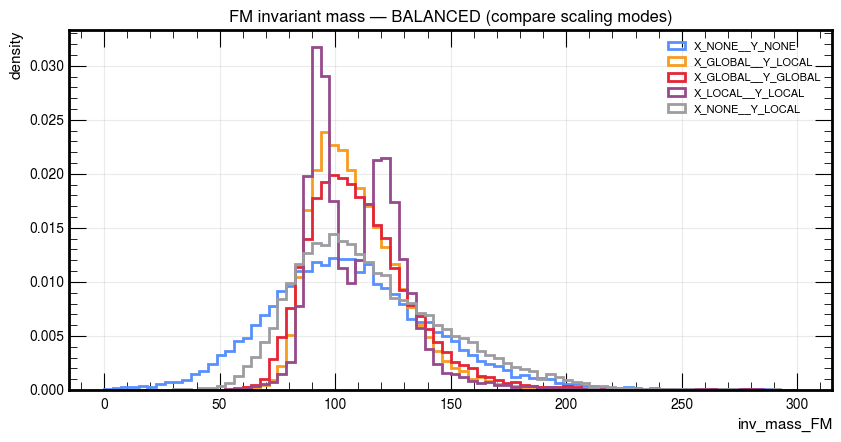

In [20]:
massesPlots.plot_mass_overlay(
    masses_bal,
    title="FM invariant mass — BALANCED (compare scaling modes)",
    bins=80,
    range_=(0, 300), 
    density=True,
)

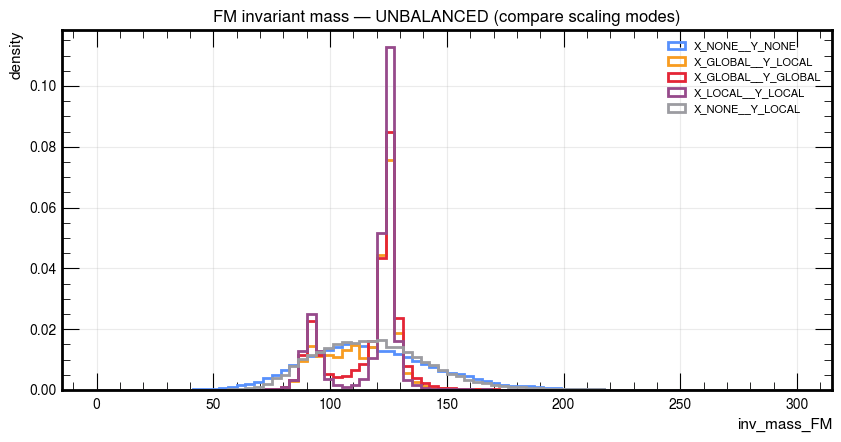

In [21]:
massesPlots.plot_mass_overlay(
    masses_unbal,
    title="FM invariant mass — UNBALANCED (compare scaling modes)",
    bins=80,
    range_=(0, 300),
    density=True,
)

In [22]:
m_dy_bal = (df_test_bal["class"].to_numpy() == 0)
m_h_bal  = (df_test_bal["class"].to_numpy() == 1)

m_dy_unb = (df_test_all["class"].to_numpy() == 0)
m_h_unb  = (df_test_all["class"].to_numpy() == 1)

# BALANCED
masses_bal_dy = {mode: np.asarray(masses_bal[mode])[m_dy_bal] for mode in SCALING_MODES}
masses_bal_h  = {mode: np.asarray(masses_bal[mode])[m_h_bal]  for mode in SCALING_MODES}

# UNBALANCED
masses_unb_dy = {mode: np.asarray(masses_unbal[mode])[m_dy_unb] for mode in SCALING_MODES}
masses_unb_h  = {mode: np.asarray(masses_unbal[mode])[m_h_unb]  for mode in SCALING_MODES}

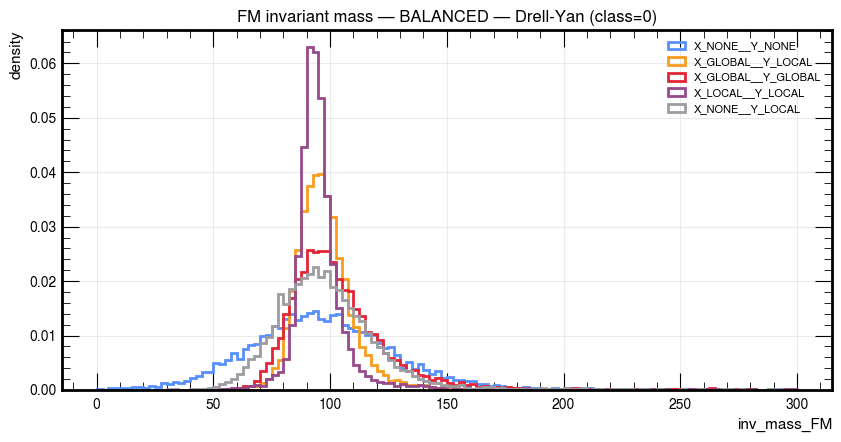

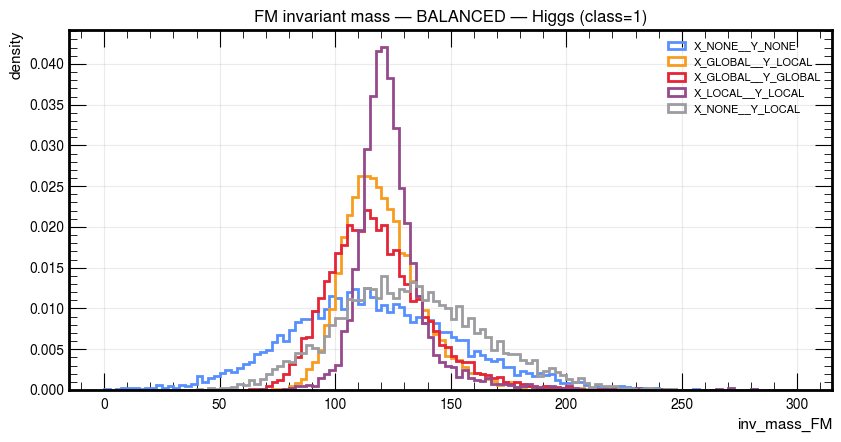

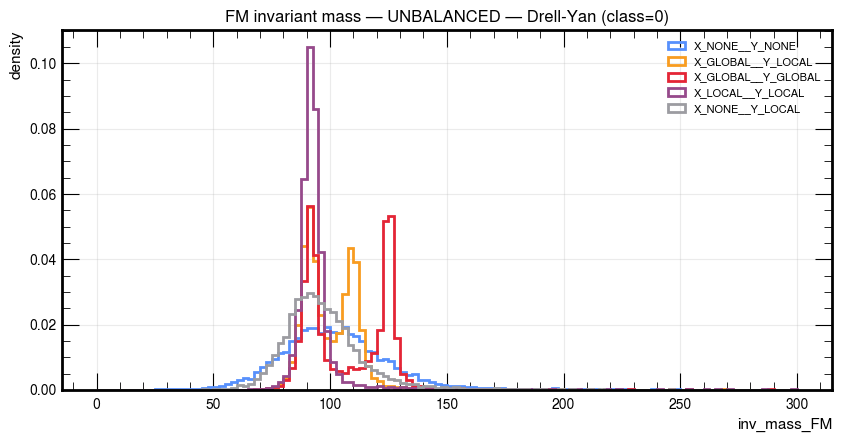

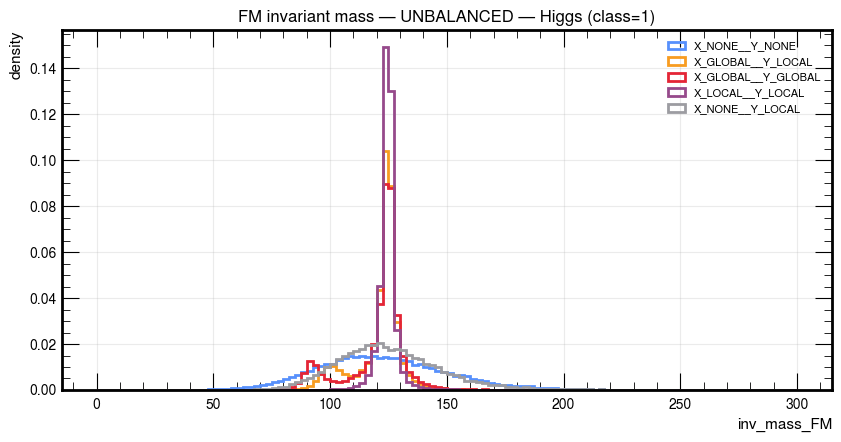

In [23]:
common_range = (0, 300) 

# BALANCED
massesPlots.plot_mass_overlay(
    masses_bal_dy,
    title="FM invariant mass — BALANCED — Drell-Yan (class=0)",
    bins=120,
    range_=common_range,
    density=True,
)

massesPlots.plot_mass_overlay(
    masses_bal_h,
    title="FM invariant mass — BALANCED — Higgs (class=1)",
    bins=120,
    range_=common_range,
    density=True,
)

# UNBALANCED
massesPlots.plot_mass_overlay(
    masses_unb_dy,
    title="FM invariant mass — UNBALANCED — Drell-Yan (class=0)",
    bins=120,
    range_=common_range,
    density=True,
)

massesPlots.plot_mass_overlay(
    masses_unb_h,
    title="FM invariant mass — UNBALANCED — Higgs (class=1)",
    bins=120,
    range_=common_range,
    density=True,
)

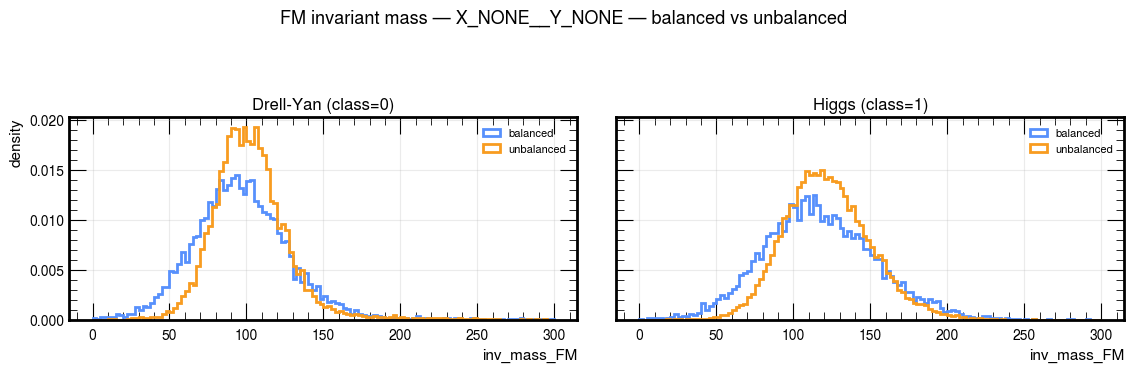

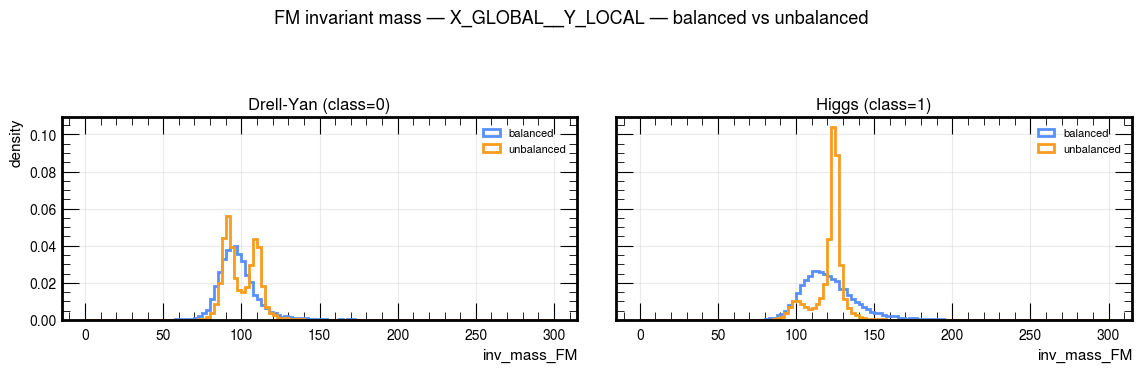

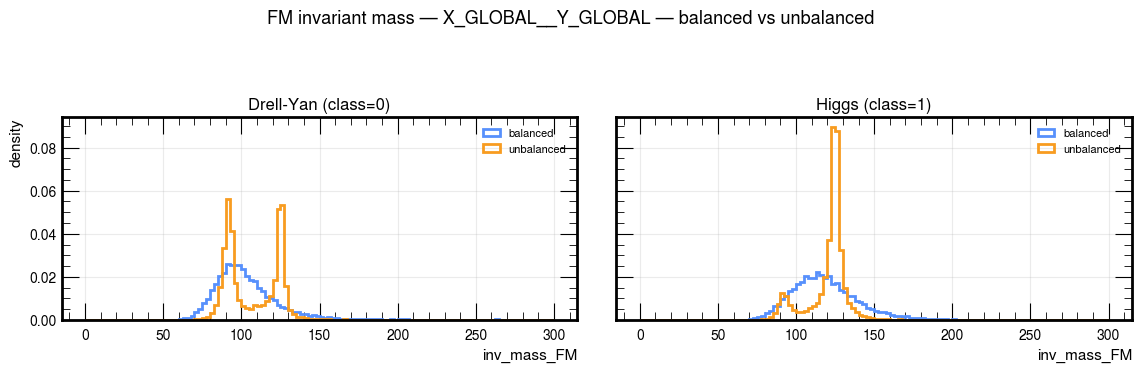

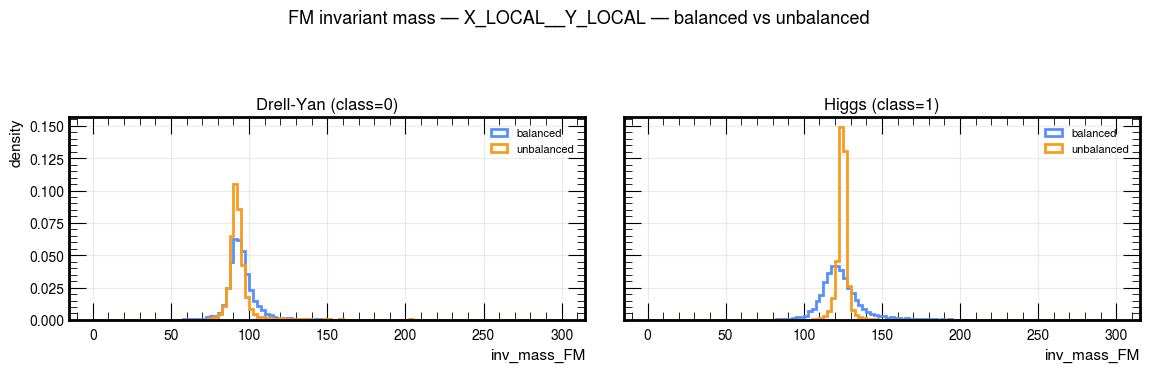

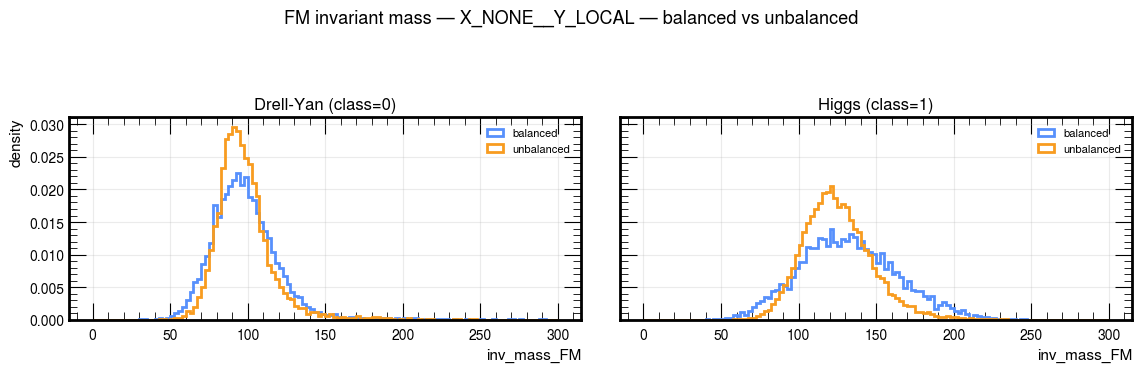

In [36]:
massesPlots.plot_balanced_vs_unbalanced_by_mode(
    masses_bal=masses_bal,
    masses_unbal=masses_unbal,
    df_test_bal=df_test_bal,
    df_test_unbal=df_test_all,
    scaling_modes=SCALING_MODES,
    bins=120,
    range_=(0, 300), 
    density=True,
)

In [38]:
# Saving the masses - new (uso un nome inequivocabile per quando farò fine-tuning):
OUT = "../results/masses"
os.makedirs(OUT, exist_ok=True)

np.savez_compressed(
    os.path.join(OUT, "masses_bal_nonflat_mse_verified.npz"),
    **{mode: np.asarray(masses_bal[mode]) for mode in SCALING_MODES}
)

np.savez_compressed(
    os.path.join(OUT, "masses_unbal_nonflat_mse_verified.npz"),
    **{mode: np.asarray(masses_unbal[mode]) for mode in SCALING_MODES}
)

print("Saved verified non-flat MSE masses ->", OUT)

Saved verified non-flat MSE masses -> ../results/masses


In [40]:
# Salvo separatamente le masse Higgs e Drell-Yan così da poterle riutilizzare:
# masks balanced
m_dy_bal = df_test_bal["class"].to_numpy() == 0
m_h_bal  = df_test_bal["class"].to_numpy() == 1

# masks unbalanced
m_dy_unb = df_test_all["class"].to_numpy() == 0
m_h_unb  = df_test_all["class"].to_numpy() == 1

# split masses by class
masses_bal_dy = {
    mode: np.asarray(masses_bal[mode])[m_dy_bal]
    for mode in SCALING_MODES
}
masses_bal_h = {
    mode: np.asarray(masses_bal[mode])[m_h_bal]
    for mode in SCALING_MODES
}

masses_unbal_dy = {
    mode: np.asarray(masses_unbal[mode])[m_dy_unb]
    for mode in SCALING_MODES
}
masses_unbal_h = {
    mode: np.asarray(masses_unbal[mode])[m_h_unb]
    for mode in SCALING_MODES
}

OUT = "../results/masses"
os.makedirs(OUT, exist_ok=True)

np.savez_compressed(
    os.path.join(OUT, "masses_bal_nonflat_mse_dy.npz"),
    **{mode: np.asarray(masses_bal_dy[mode]) for mode in SCALING_MODES}
)

np.savez_compressed(
    os.path.join(OUT, "masses_bal_nonflat_mse_h.npz"),
    **{mode: np.asarray(masses_bal_h[mode]) for mode in SCALING_MODES}
)

np.savez_compressed(
    os.path.join(OUT, "masses_unbal_nonflat_mse_dy.npz"),
    **{mode: np.asarray(masses_unbal_dy[mode]) for mode in SCALING_MODES}
)

np.savez_compressed(
    os.path.join(OUT, "masses_unbal_nonflat_mse_h.npz"),
    **{mode: np.asarray(masses_unbal_h[mode]) for mode in SCALING_MODES}
)

print("Saved class-separated non-flat MSE masses.")

Saved class-separated non-flat MSE masses.


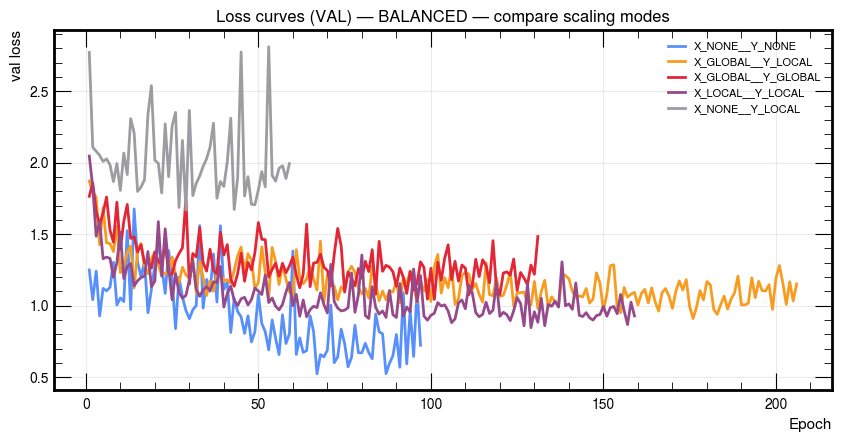

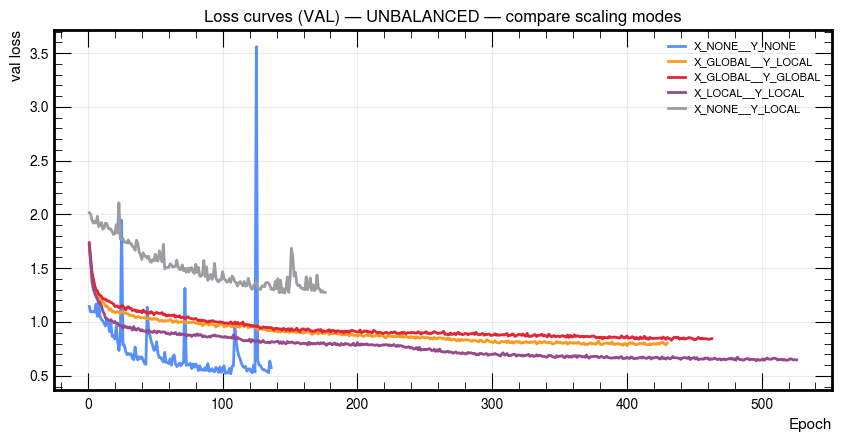

In [26]:
lossPlots.plot_loss_overlay(
    results_balanced,
    title="Loss curves (VAL) — BALANCED — compare scaling modes",
    which="val",
    logy=False,      
)

lossPlots.plot_loss_overlay(
    results_unbalanced,
    title="Loss curves (VAL) — UNBALANCED — compare scaling modes",
    which="val",
)

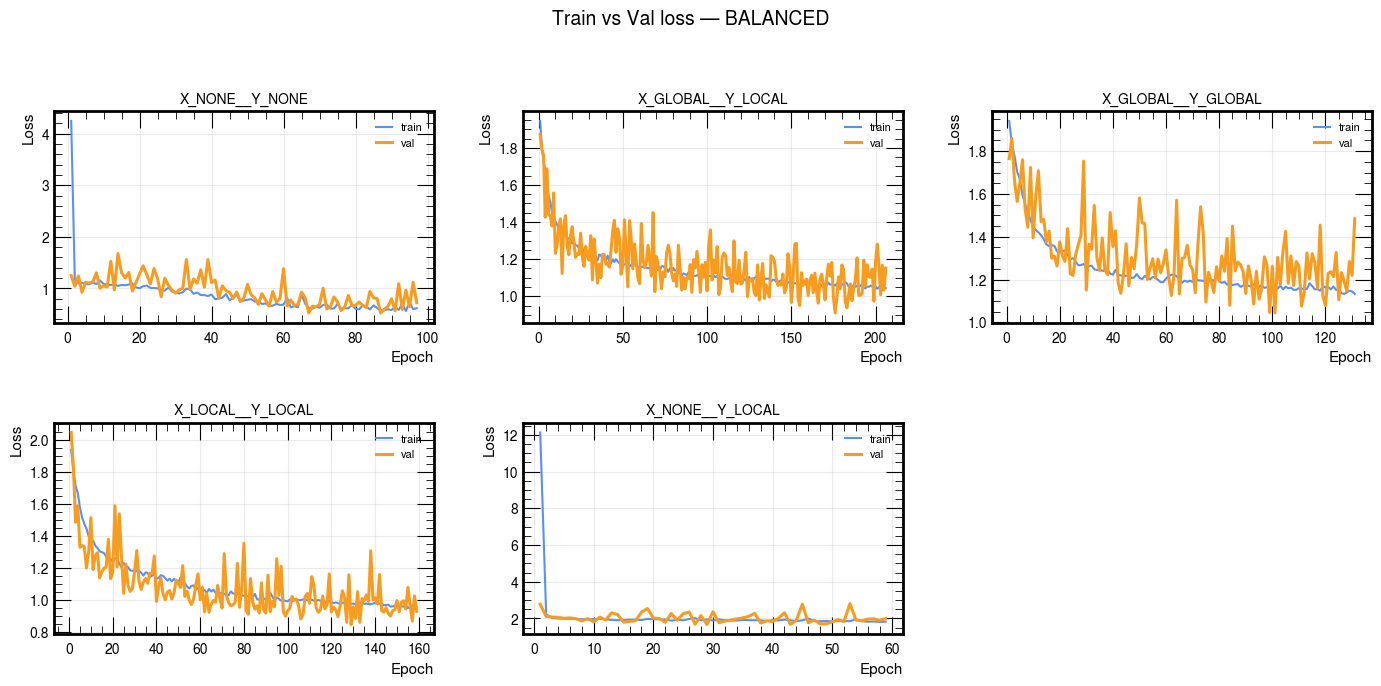

In [27]:
lossPlots.plot_loss_grid(
    results_balanced,
    title="Train vs Val loss — BALANCED",
    order=SCALING_MODES,
    ncols=3,
)

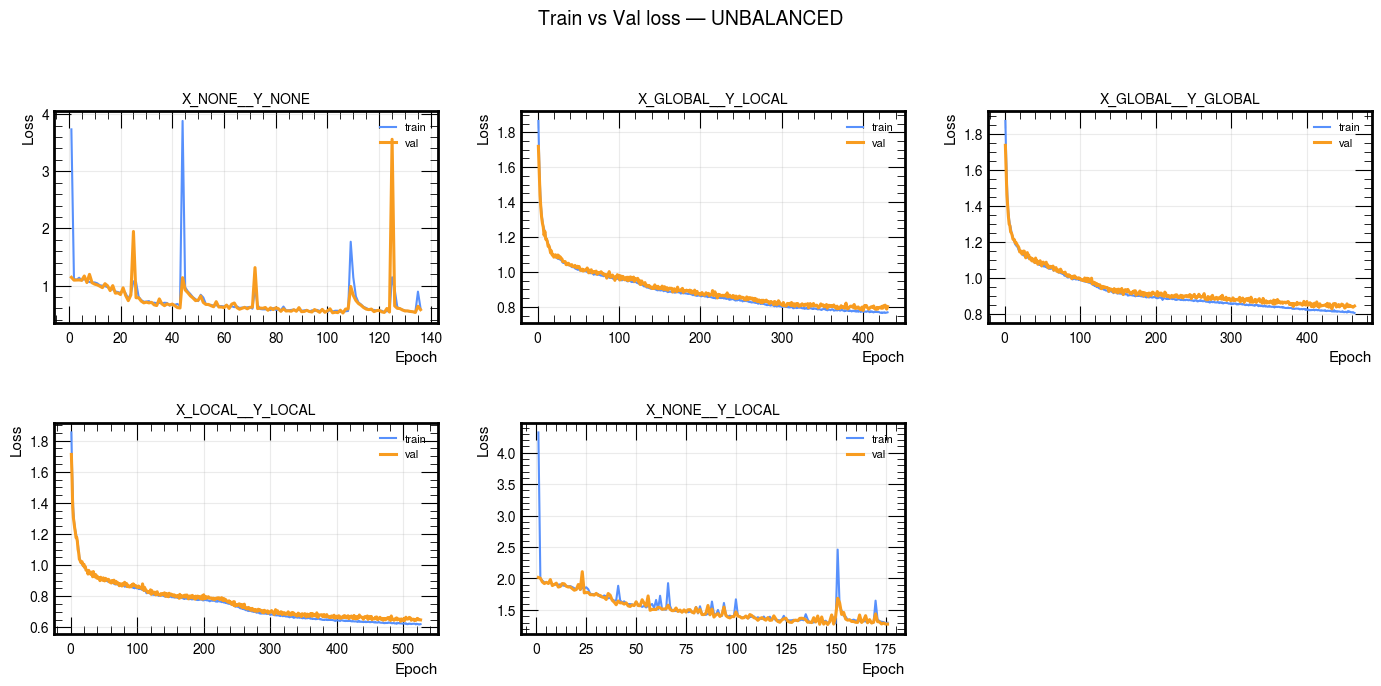

In [28]:
lossPlots.plot_loss_grid(
    results_unbalanced,
    title="Train vs Val loss — UNBALANCED",
    order=SCALING_MODES,
    ncols=3,
)

# Analysis
- S/B within the window (110-130) GeV

In [62]:
print("S/B:")
tab_long, tab_pivot = analysis.compute_S_over_B_all_modes(
    masses_bal=masses_bal,
    masses_unbal=masses_unbal,
    df_test_bal=df_test_bal,
    df_test_unbal=df_test_all,
    scaling_modes=SCALING_MODES,
    window=(110,140),
    save_csv=True,
)

tab_pivot

S/B:


,mode,balanced,unbalanced
0,X_GLOBAL__Y_GLOBAL,2.123332,5.524507
1,X_GLOBAL__Y_LOCAL,5.328228,13.615140
2,X_LOCAL__Y_LOCAL,15.292056,111.115044
3,X_NONE__Y_LOCAL,1.786013,11.314578
4,X_NONE__Y_NONE,1.329169,4.685378


## CHECK :

In [63]:
# Conto separatamente S e B per il best mode:
tab_long[tab_long["mode"] == "X_LOCAL__Y_LOCAL"]

,dataset,mode,window,N_S,N_B,S_over_B,S_over_sqrtB
6,balanced,X_LOCAL__Y_LOCAL,110-140,6545,428,15.292056,316.364516
7,unbalanced,X_LOCAL__Y_LOCAL,110-140,25112,226,111.115044,1670.425392


In [64]:
mode = "X_LOCAL__Y_LOCAL"
m = masses_bal[mode]
df = df_test_bal
assert len(m) == len(df)

# verifico: DY e Higgs hanno distribuzioni ragionevoli separatamente
mask_h = df["class"].to_numpy() == 1
mask_d = df["class"].to_numpy() == 0

print("mean mass Higgs:", np.mean(m[mask_h]), "std:", np.std(m[mask_h]))
print("mean mass DY   :", np.mean(m[mask_d]), "std:", np.std(m[mask_d]))

mean mass Higgs: 124.2627158721147 std: 16.74048870694653
mean mass DY   : 98.0049437181621 std: 26.140236363712937


# New Test
- Applico gli scaler di Higgs anche a DY nell'inference

In [43]:
import importlib
import fm.model
importlib.reload(fm.model)

<module 'fm.model' from '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/fm/model.py'>

In [51]:
masses_dy_standard = {}
masses_dy_higgs_scaler = {}
masses_h_standard = {}

df_test_dy = df_test_all[df_test_all["class"] == 0].copy()
df_test_h  = df_test_all[df_test_all["class"] == 1].copy()

for mode in SCALING_MODES:
    res = results_unbalanced[mode]

    # --- predictions
    df_pred_dy_standard = model.predict_tau_corr_auto_new(
        df=df_test_dy,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    df_pred_dy_higgs_scaler = model.predict_tau_corr_auto_new(
        df=df_test_dy,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
        forced_scaler_class=1,   # use Higgs scalers on DY test
    )

    df_pred_h_standard = model.predict_tau_corr_auto_new(
        df=df_test_h,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    # --- masses
    masses_dy_standard[mode] = physics.inv_mass_two_taus_corrected_ratio(
        df_test_dy["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_dy["tau1_eta"].to_numpy(),
        df_test_dy["tau1_phi"].to_numpy(),
        df_test_dy["tau1_mass"].to_numpy(),
        df_pred_dy_standard["tau1_corr_pred"].to_numpy(),
        df_test_dy["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_dy["tau2_eta"].to_numpy(),
        df_test_dy["tau2_phi"].to_numpy(),
        df_test_dy["tau2_mass"].to_numpy(),
        df_pred_dy_standard["tau2_corr_pred"].to_numpy(),
    )

    masses_dy_higgs_scaler[mode] = physics.inv_mass_two_taus_corrected_ratio(
        df_test_dy["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_dy["tau1_eta"].to_numpy(),
        df_test_dy["tau1_phi"].to_numpy(),
        df_test_dy["tau1_mass"].to_numpy(),
        df_pred_dy_higgs_scaler["tau1_corr_pred"].to_numpy(),
        df_test_dy["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_dy["tau2_eta"].to_numpy(),
        df_test_dy["tau2_phi"].to_numpy(),
        df_test_dy["tau2_mass"].to_numpy(),
        df_pred_dy_higgs_scaler["tau2_corr_pred"].to_numpy(),
    )

    masses_h_standard[mode] = physics.inv_mass_two_taus_corrected_ratio(
        df_test_h["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_h["tau1_eta"].to_numpy(),
        df_test_h["tau1_phi"].to_numpy(),
        df_test_h["tau1_mass"].to_numpy(),
        df_pred_h_standard["tau1_corr_pred"].to_numpy(),
        df_test_h["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_h["tau2_eta"].to_numpy(),
        df_test_h["tau2_phi"].to_numpy(),
        df_test_h["tau2_mass"].to_numpy(),
        df_pred_h_standard["tau2_corr_pred"].to_numpy(),
    )

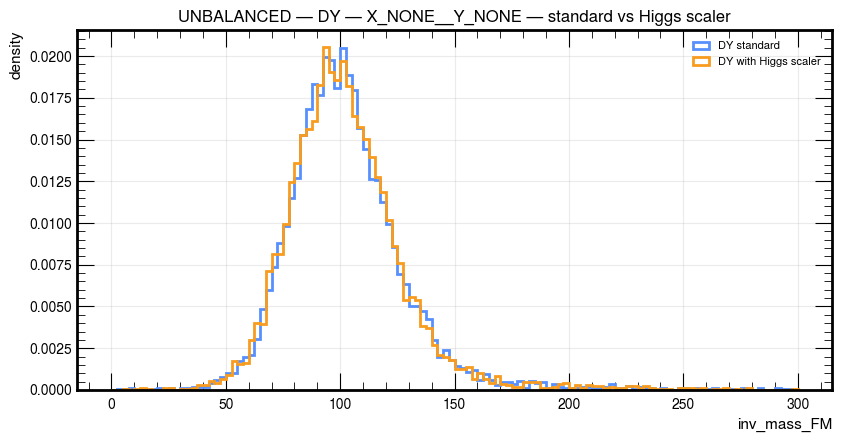

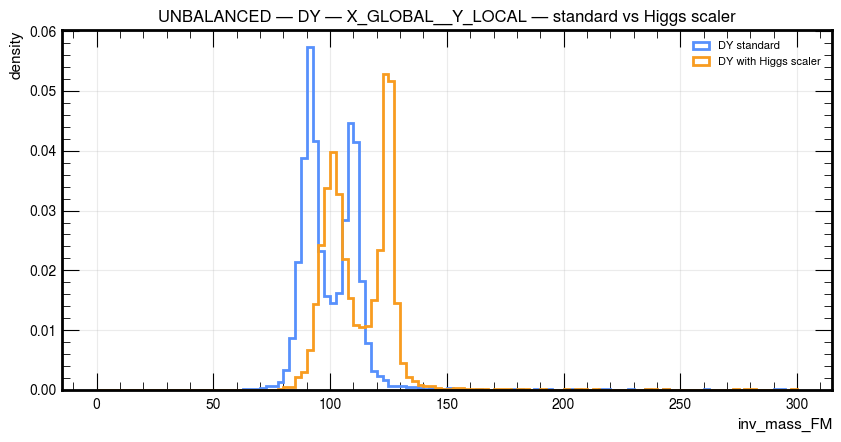

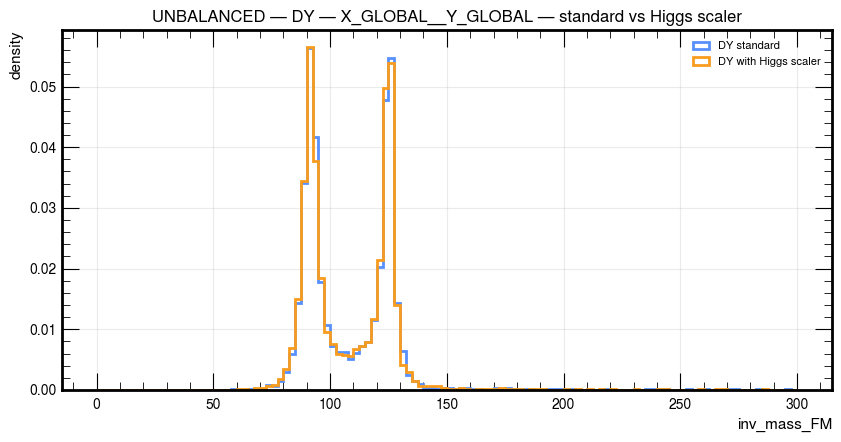

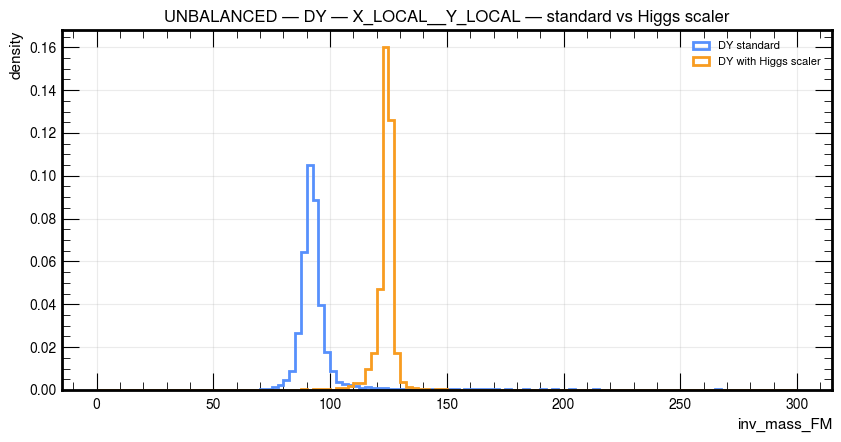

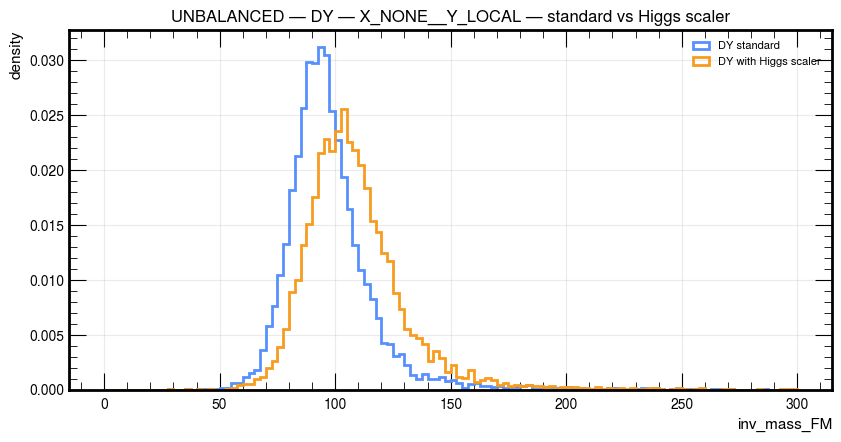

In [52]:
common_range = (0, 300)

for mode in SCALING_MODES:
    massesPlots.plot_mass_overlay(
        {
            "DY standard": masses_dy_standard[mode],
            "DY with Higgs scaler": masses_dy_higgs_scaler[mode],
        },
        title=f"UNBALANCED — DY — {mode} — standard vs Higgs scaler",
        bins=120,
        range_=common_range,
        density=True,
    )

In [55]:
# balanced:

masses_dy_standard_bal = {}
masses_dy_higgs_scaler_bal = {}
masses_h_standard_bal = {}

df_test_dy_bal = df_test_bal[df_test_bal["class"] == 0].copy()
df_test_h_bal  = df_test_bal[df_test_bal["class"] == 1].copy()

for mode in SCALING_MODES:
    res = results_balanced[mode]

    # --- predictions
    df_pred_dy_standard_bal = model.predict_tau_corr_auto_new(
        df=df_test_dy_bal,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    df_pred_dy_higgs_scaler_bal = model.predict_tau_corr_auto_new(
        df=df_test_dy_bal,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
        forced_scaler_class=1,   # use Higgs scalers on DY test
    )

    df_pred_h_standard_bal = model.predict_tau_corr_auto_new(
        df=df_test_h_bal,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    # --- masses
    masses_dy_standard_bal[mode] = physics.inv_mass_two_taus_corrected_ratio(
        df_test_dy_bal["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_dy_bal["tau1_eta"].to_numpy(),
        df_test_dy_bal["tau1_phi"].to_numpy(),
        df_test_dy_bal["tau1_mass"].to_numpy(),
        df_pred_dy_standard_bal["tau1_corr_pred"].to_numpy(),
        df_test_dy_bal["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_dy_bal["tau2_eta"].to_numpy(),
        df_test_dy_bal["tau2_phi"].to_numpy(),
        df_test_dy_bal["tau2_mass"].to_numpy(),
        df_pred_dy_standard_bal["tau2_corr_pred"].to_numpy(),
    )

    masses_dy_higgs_scaler_bal[mode] = physics.inv_mass_two_taus_corrected_ratio(
        df_test_dy_bal["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_dy_bal["tau1_eta"].to_numpy(),
        df_test_dy_bal["tau1_phi"].to_numpy(),
        df_test_dy_bal["tau1_mass"].to_numpy(),
        df_pred_dy_higgs_scaler_bal["tau1_corr_pred"].to_numpy(),
        df_test_dy_bal["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_dy_bal["tau2_eta"].to_numpy(),
        df_test_dy_bal["tau2_phi"].to_numpy(),
        df_test_dy_bal["tau2_mass"].to_numpy(),
        df_pred_dy_higgs_scaler_bal["tau2_corr_pred"].to_numpy(),
    )

    masses_h_standard_bal[mode] = physics.inv_mass_two_taus_corrected_ratio(
        df_test_h_bal["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_h_bal["tau1_eta"].to_numpy(),
        df_test_h_bal["tau1_phi"].to_numpy(),
        df_test_h_bal["tau1_mass"].to_numpy(),
        df_pred_h_standard_bal["tau1_corr_pred"].to_numpy(),
        df_test_h_bal["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_h_bal["tau2_eta"].to_numpy(),
        df_test_h_bal["tau2_phi"].to_numpy(),
        df_test_h_bal["tau2_mass"].to_numpy(),
        df_pred_h_standard_bal["tau2_corr_pred"].to_numpy(),
    )

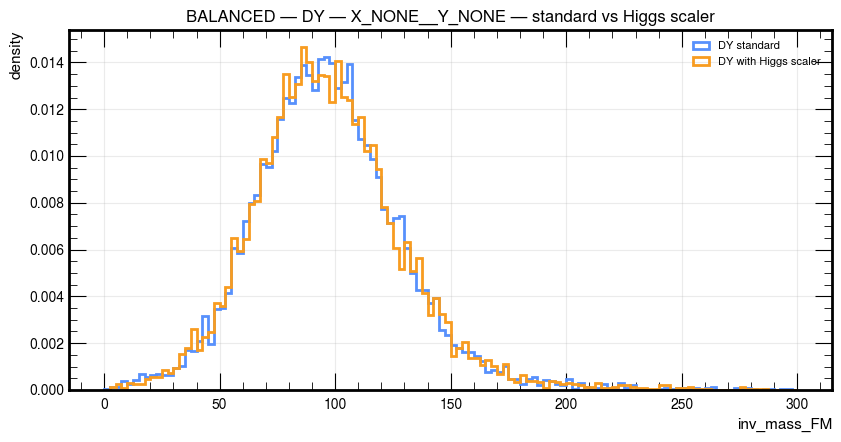

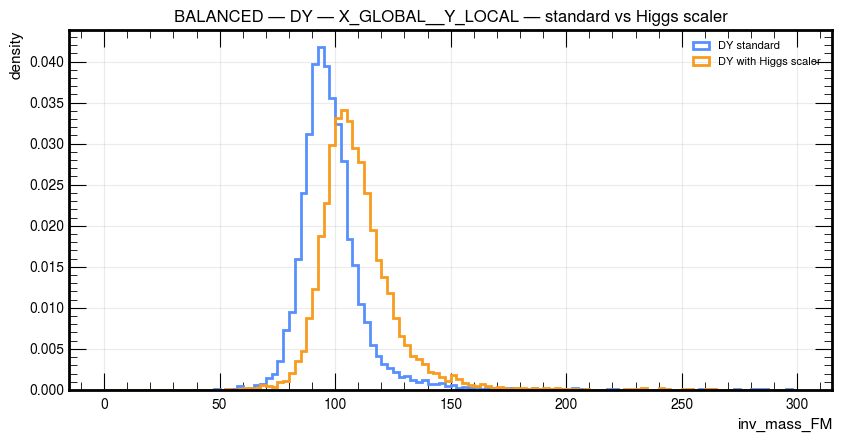

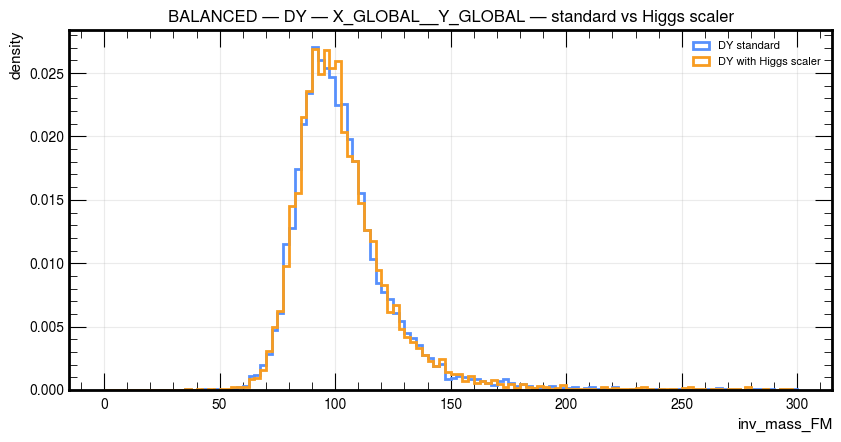

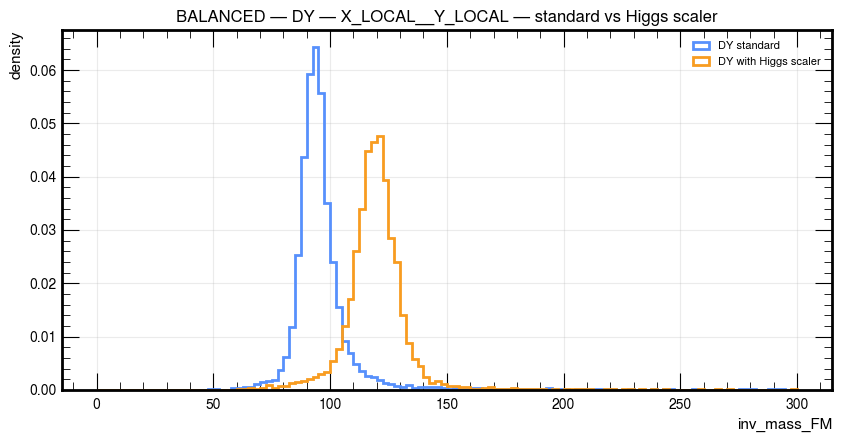

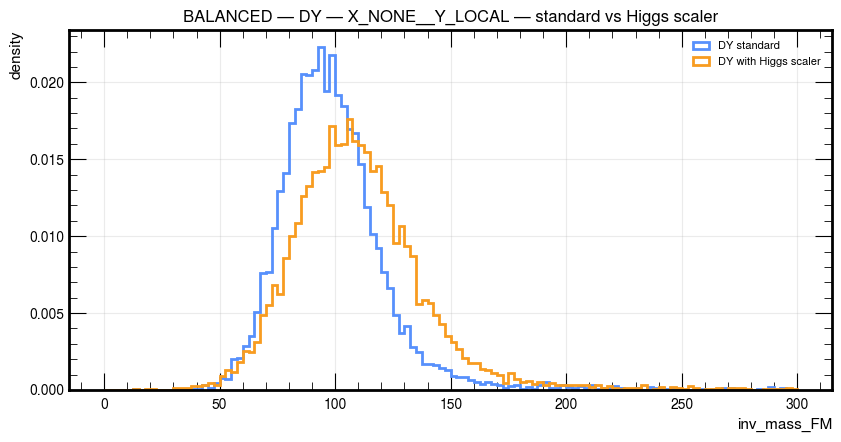

In [56]:
common_range = (0, 300)

for mode in SCALING_MODES:
    massesPlots.plot_mass_overlay(
        {
            "DY standard": masses_dy_standard_bal[mode],
            "DY with Higgs scaler": masses_dy_higgs_scaler_bal[mode],
        },
        title=f"BALANCED — DY — {mode} — standard vs Higgs scaler",
        bins=120,
        range_=common_range,
        density=True,
    )

In [61]:
for mode in SCALING_MODES:
    
    peak_standard = analysis.find_peak_position(masses_dy_standard[mode])
    peak_higgs_scaler = analysis.find_peak_position(masses_dy_higgs_scaler[mode])
    
    print(f"{mode}")
    print(f"  DY peak standard      : {peak_standard:.2f} GeV")
    print(f"  DY peak Higgs scaler  : {peak_higgs_scaler:.2f} GeV")

X_NONE__Y_NONE
  DY peak standard      : 101.25 GeV
  DY peak Higgs scaler  : 93.75 GeV
X_GLOBAL__Y_LOCAL
  DY peak standard      : 91.25 GeV
  DY peak Higgs scaler  : 123.75 GeV
X_GLOBAL__Y_GLOBAL
  DY peak standard      : 91.25 GeV
  DY peak Higgs scaler  : 91.25 GeV
X_LOCAL__Y_LOCAL
  DY peak standard      : 91.25 GeV
  DY peak Higgs scaler  : 123.75 GeV
X_NONE__Y_LOCAL
  DY peak standard      : 93.75 GeV
  DY peak Higgs scaler  : 103.75 GeV


# Salvataggio per comparison

In [10]:
results_unbalanced_mse_pat30 = {}

OUT_ROOT = "../results/runs_prepared"
dataset_tag = "unbalanced"

for mode in SCALING_MODES:
    save_dir = os.path.join(OUT_ROOT, dataset_tag, mode)
    res = training.load_run(save_dir)
    results_unbalanced_mse_pat30[mode] = res
    print("Loaded MSE pat30:", mode)

results_balanced_mse_pat30 = {}

dataset_tag = "balanced"

for mode in SCALING_MODES:
    save_dir = os.path.join(OUT_ROOT, dataset_tag, mode)
    res = training.load_run(save_dir)
    results_balanced_mse_pat30[mode] = res
    print("Loaded MSE pat30:", mode)



Loaded MSE pat30: X_NONE__Y_NONE
Loaded MSE pat30: X_GLOBAL__Y_LOCAL
Loaded MSE pat30: X_GLOBAL__Y_GLOBAL
Loaded MSE pat30: X_LOCAL__Y_LOCAL
Loaded MSE pat30: X_NONE__Y_LOCAL
Loaded MSE pat30: X_NONE__Y_NONE
Loaded MSE pat30: X_GLOBAL__Y_LOCAL
Loaded MSE pat30: X_GLOBAL__Y_GLOBAL
Loaded MSE pat30: X_LOCAL__Y_LOCAL
Loaded MSE pat30: X_NONE__Y_LOCAL


In [11]:
preds_bal_mse_pat30 = {}

for mode in SCALING_MODES:

    res = results_balanced_mse_pat30[mode]

    df_pred = model.predict_tau_corr_auto(
        df=df_test_bal,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    preds_bal_mse_pat30[mode] = df_pred

preds_unbal_mse_pat30 = {}

for mode in SCALING_MODES:

    res = results_unbalanced_mse_pat30[mode]

    df_pred = model.predict_tau_corr_auto(
        df=df_test_all,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    preds_unbal_mse_pat30[mode] = df_pred

In [12]:
masses_bal_mse_pat30 = {}

for mode in SCALING_MODES:

    dfp = preds_bal_mse_pat30[mode]

    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_bal["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau1_eta"].to_numpy(),
        df_test_bal["tau1_phi"].to_numpy(),
        df_test_bal["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_bal["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau2_eta"].to_numpy(),
        df_test_bal["tau2_phi"].to_numpy(),
        df_test_bal["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_bal_mse_pat30[mode] = m

masses_unbal_mse_pat30 = {}

for mode in SCALING_MODES:

    dfp = preds_unbal_mse_pat30[mode]

    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_all["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau1_eta"].to_numpy(),
        df_test_all["tau1_phi"].to_numpy(),
        df_test_all["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_all["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau2_eta"].to_numpy(),
        df_test_all["tau2_phi"].to_numpy(),
        df_test_all["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_unbal_mse_pat30[mode] = m

In [13]:
np.savez(
    "../results/masses/masses_bal_nonflat_mse_pat30.npz",
    **masses_bal_mse_pat30
)

np.savez(
    "../results/masses/masses_unbal_nonflat_mse_pat30.npz",
    **masses_unbal_mse_pat30
)